### import the required libraries

In [2]:
# 处理库
import pandas as pd
import numpy as np

# 可视化库
import matplotlib.pyplot as plt
import seaborn as sns


import warnings



warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

### loading datasets

In [3]:
labeled_df = pd.read_csv('./data/train.csv')
unlabeled_df = pd.read_csv('./data/test.csv')

# 加载其他数据
ad = pd.read_csv('./data/ad.csv')
app_cat = pd.read_csv('./data/app_categories.csv')
position = pd.read_csv('./data/position.csv')
user_app_actions = pd.read_csv('./data/user_app_actions.csv')
user_installedapps = pd.read_csv('./data/user_installedapps.csv')
user = pd.read_csv('./data/user.csv')

### Exploratory data analysis

In [750]:
# 转化率
labeled_df['label'].mean()
# 高度不平衡

0.02487299734793286

#### data cleaning

In [4]:
# check columns and shape of train and test set
print('labeled_df columns:',labeled_df.columns)
print("labeled_df set shape:",labeled_df.shape)



labeled_df columns: Index(['label', 'clickTime', 'conversionTime', 'creativeID', 'userID',
       'positionID', 'connectionType', 'telecomsOperator'],
      dtype='object')
labeled_df set shape: (3749528, 8)


In [5]:
# 重复值检验
print(labeled_df.duplicated().sum())


57423


In [6]:
# 处理重复值
labeled_df.drop_duplicates(keep = 'first',inplace = True)

In [7]:
# 缺失值检验
labeled_df.isnull().sum()

label                     0
clickTime                 0
conversionTime      3598844
creativeID                0
userID                    0
positionID                0
connectionType            0
telecomsOperator          0
dtype: int64

In [8]:
# 处理缺失值,删除conversionTime列
labeled_df.drop(columns = ['conversionTime'],inplace = True)


In [9]:
labeled_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3692105 entries, 0 to 3749527
Data columns (total 7 columns):
 #   Column            Dtype
---  ------            -----
 0   label             int64
 1   clickTime         int64
 2   creativeID        int64
 3   userID            int64
 4   positionID        int64
 5   connectionType    int64
 6   telecomsOperator  int64
dtypes: int64(7)
memory usage: 225.3 MB


In [10]:
# 检查其他表的缺失值和重复值
def missing_duplicated_values(df_clean):
    '''
    检查其他表的缺失值和重复值
    :param df_clean: 输入的DataFrame
    :return: None
    '''
    print(df_clean.isnull().sum())
    print(df_clean.duplicated().sum())

# 定义数据集列表
datasets = [ad, 
            user, 
            app_cat, 
            position, 
            user_app_actions, 
            user_installedapps ]

# 遍历
for dataset in datasets:
    missing_duplicated_values(dataset)
    print(
        '-----------------'
    )

    

creativeID      0
adID            0
camgaignID      0
advertiserID    0
appID           0
appPlatform     0
dtype: int64
0
-----------------
userID            0
age               0
gender            0
education         0
marriageStatus    0
haveBaby          0
hometown          0
residence         0
dtype: int64
0
-----------------
appID          0
appCategory    0
dtype: int64
0
-----------------
positionID      0
sitesetID       0
positionType    0
dtype: int64
0
-----------------
userID         0
installTime    0
appID          0
dtype: int64
0
-----------------
userID    0
appID     0
dtype: int64
0
-----------------


#### Multi - dimensional conversion rate analysis 

In [11]:
# 所有数据集的列名

# 打印labeled_df的列名
print(labeled_df.columns)

# 遍历其他数据集的列名
for dataset in datasets:
    print(dataset.columns)

Index(['label', 'clickTime', 'creativeID', 'userID', 'positionID',
       'connectionType', 'telecomsOperator'],
      dtype='object')
Index(['creativeID', 'adID', 'camgaignID', 'advertiserID', 'appID',
       'appPlatform'],
      dtype='object')
Index(['userID', 'age', 'gender', 'education', 'marriageStatus', 'haveBaby',
       'hometown', 'residence'],
      dtype='object')
Index(['appID', 'appCategory'], dtype='object')
Index(['positionID', 'sitesetID', 'positionType'], dtype='object')
Index(['userID', 'installTime', 'appID'], dtype='object')
Index(['userID', 'appID'], dtype='object')


##### ad维度

In [12]:
# 1.合并ad数据集
if "adID" not in labeled_df.columns:
    labeled_df = pd.merge(left = labeled_df, right = ad, on = 'creativeID', how = 'left')

# 重命名campaignID列
labeled_df['campaignID'] = labeled_df['camgaignID']
labeled_df.drop(columns = ['camgaignID'], inplace = True)


In [13]:
# 查看数据列名
labeled_df.columns

Index(['label', 'clickTime', 'creativeID', 'userID', 'positionID',
       'connectionType', 'telecomsOperator', 'adID', 'advertiserID', 'appID',
       'appPlatform', 'campaignID'],
      dtype='object')

In [14]:
# 统计creativeID、adID、campaignID、advertiserID的唯一值数
print(labeled_df['creativeID'].nunique())
print(labeled_df['adID'].nunique())
print(labeled_df['campaignID'].nunique())
print(labeled_df['advertiserID'].nunique())


6315
3447
677
89


In [15]:
# 1.1 哪些广告素材转化率高？
creative_stats = labeled_df.groupby('creativeID').agg(
    count=('label', 'count'),
    cvr=('label', 'mean')
).reset_index()

# 筛选计数> = 50 ,按cvr降序
creative_filtered = creative_stats[creative_stats['count']>=50].sort_values(by='cvr',ascending=False)
print(creative_filtered.head(10))
print(creative_filtered.describe())

      creativeID  count       cvr
1461        1516    140  0.407143
1102        1142    896  0.334821
6005        6255    346  0.326590
4057        4215    743  0.312248
2442        2544     89  0.258427
4309        4479    115  0.252174
3408        3545    921  0.248643
4069        4228   9675  0.232661
939          973  12151  0.215785
1717        1784    145  0.213793
        creativeID          count          cvr
count  2049.000000    2049.000000  2049.000000
mean   3237.583699    1771.988775     0.017996
std    1891.375692   12748.865022     0.033735
min       6.000000      50.000000     0.000000
25%    1581.000000      88.000000     0.000000
50%    3268.000000     168.000000     0.007353
75%    4852.000000     479.000000     0.020000
max    6581.000000  449067.000000     0.407143


In [16]:
# 1.2  哪些广告的转化率高？
ad_stats = labeled_df.groupby('adID').agg(
    count=('label', 'count'),
    cvr=('label', 'mean')
).reset_index()

# 选择计数 >= 50 且按 cvr 排序的广告
ad_filtered = ad_stats[ad_stats['count'] >= 50].sort_values('cvr', ascending=False)
print(ad_filtered.head(10))
print(ad_filtered.describe())

      adID  count       cvr
2347  2462    140  0.407143
2491  2611    896  0.334821
1933  2018    346  0.326590
2199  2307    743  0.312248
807    844     89  0.258427
729    761   9675  0.232661
2363  2480  12151  0.215785
1119  1175    145  0.213793
3398  3561    690  0.213043
486    506    960  0.189583
              adID          count          cvr
count  1620.000000    1620.000000  1620.000000
mean   1788.559877    2259.983333     0.017967
std    1061.732495   18502.306188     0.033244
min       4.000000      50.000000     0.000000
25%     854.750000      99.000000     0.000000
50%    1757.500000     198.500000     0.007524
75%    2745.500000     591.500000     0.019556
max    3616.000000  596200.000000     0.407143


In [17]:
# 1.3 哪些推广计划的转化率高？
campaign_stats = labeled_df.groupby('campaignID').agg(
    count=('label', 'count'),
    cvr=('label', 'mean')
).reset_index()

# 选择计数 >= 50 且按 cvr 排序的推广计划
campaign_filtered = campaign_stats[campaign_stats['count'] >= 50].sort_values('cvr', ascending=False)
print(campaign_filtered.head(10))
print(campaign_filtered.describe())


     campaignID  count       cvr
286         299    140  0.407143
205         212   2140  0.321028
419         444   9675  0.232661
466         492  12151  0.215785
102         106   1050  0.190476
402         426   9736  0.182929
516         547    124  0.169355
152         158   1747  0.157985
80           84   1002  0.142715
564         600  13290  0.138525
       campaignID          count         cvr
count  499.000000     499.000000  499.000000
mean   350.432866    7392.725451    0.022861
std    213.471434   33304.557478    0.038395
min      1.000000      50.000000    0.000000
25%    161.000000     236.500000    0.001889
50%    345.000000     756.000000    0.010168
75%    528.500000    3388.000000    0.027973
max    720.000000  596200.000000    0.407143


In [18]:
# 1.4 哪些广告商的转化率高？
ad_vter_stats = labeled_df.groupby('advertiserID').agg(
    count=('label', 'count'),
    cvr=('label', 'mean')
).reset_index()

# 筛选计数>=50，按cvr降序
ad_vter_filtered = ad_vter_stats[ad_vter_stats['count'] >= 50].sort_values('cvr', ascending=False)
print(ad_vter_filtered.head(10))
print(ad_vter_filtered.describe())


    advertiserID  count       cvr
9             11    151  0.423841
78            81  32564  0.208727
3              4    129  0.162791
86            89  49645  0.114674
20            22   4527  0.113541
72            75   9684  0.112970
26            28   4641  0.083172
28            31   2016  0.071429
29            32   1032  0.069767
54            57  55606  0.067421
       advertiserID         count        cvr
count     84.000000  8.400000e+01  84.000000
mean      46.702381  4.395207e+04   0.033139
std       26.425517  2.124005e+05   0.056875
min        1.000000  5.800000e+01   0.000000
25%       24.750000  5.460000e+02   0.002856
50%       46.500000  3.185500e+03   0.015828
75%       69.500000  1.819300e+04   0.039776
max       91.000000  1.915847e+06   0.423841


##### user维度

In [19]:
# 合并user表
if 'age' not in labeled_df.columns:
    labeled_df = pd.merge(labeled_df,user , on='userID',how = 'left')


In [20]:
# 查看列名
labeled_df.columns

Index(['label', 'clickTime', 'creativeID', 'userID', 'positionID',
       'connectionType', 'telecomsOperator', 'adID', 'advertiserID', 'appID',
       'appPlatform', 'campaignID', 'age', 'gender', 'education',
       'marriageStatus', 'haveBaby', 'hometown', 'residence'],
      dtype='object')

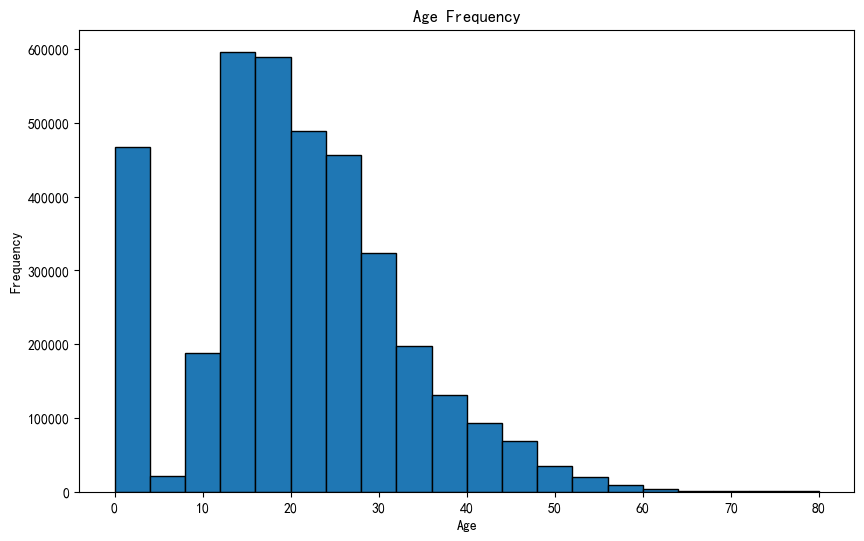

In [21]:
# 可视化age频率
plt.figure(figsize=(10, 6))
plt.hist(labeled_df['age'], bins=20, edgecolor='k')
plt.title('Age Frequency')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


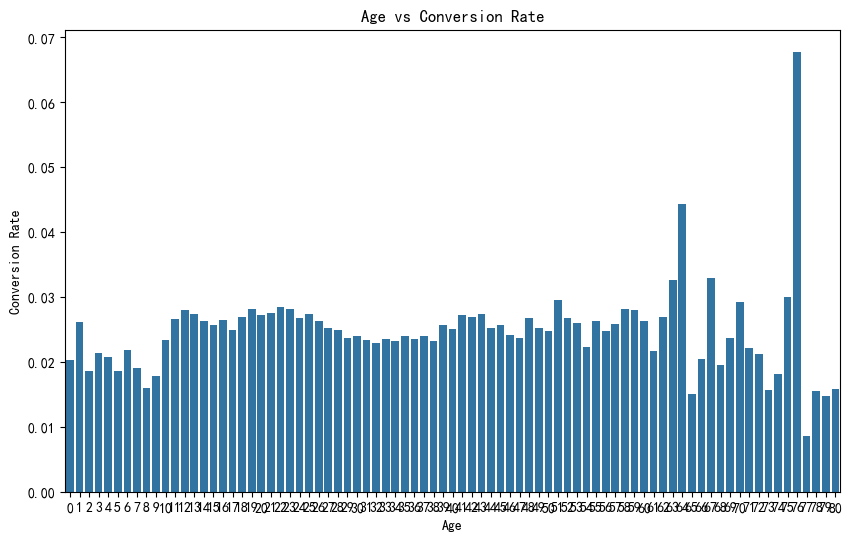

In [22]:
# 可视化age cvr

# 计算各年龄的转化率
age_cvr_df = labeled_df.groupby('age').agg(
    cvr = ('label','mean')
).reset_index()

# 可视化
plt.figure(figsize=(10,6))
sns.barplot(x='age',y='cvr',data=age_cvr_df)
plt.title('Age vs Conversion Rate')
plt.xlabel('Age')
plt.ylabel('Conversion Rate')
plt.show()


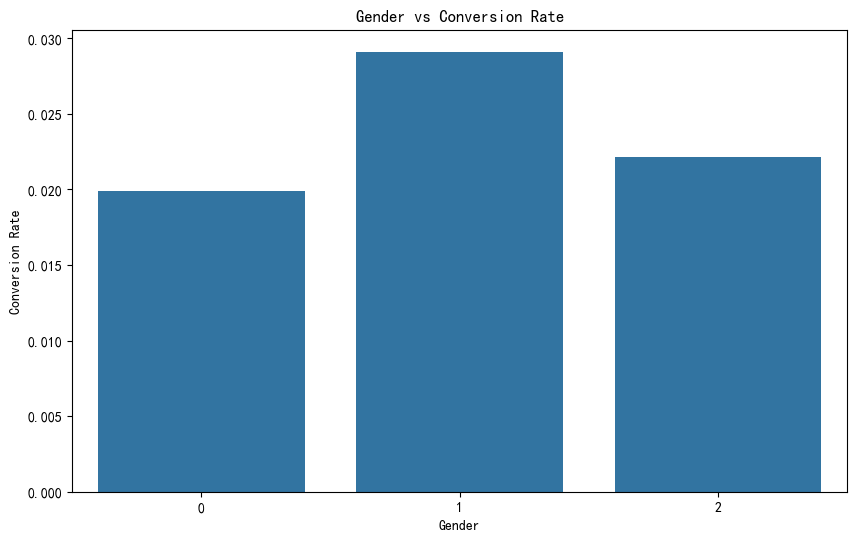

In [23]:
# 可视化gender转化率

# 统计
gender_cvr_df = labeled_df.groupby('gender').agg(
    cvr = ('label','mean')
).reset_index()

# 可视化
plt.figure(figsize=(10,6))
sns.barplot(x='gender',y='cvr',data=gender_cvr_df)
plt.title('Gender vs Conversion Rate')
plt.xlabel('Gender')
plt.ylabel('Conversion Rate')
plt.show()

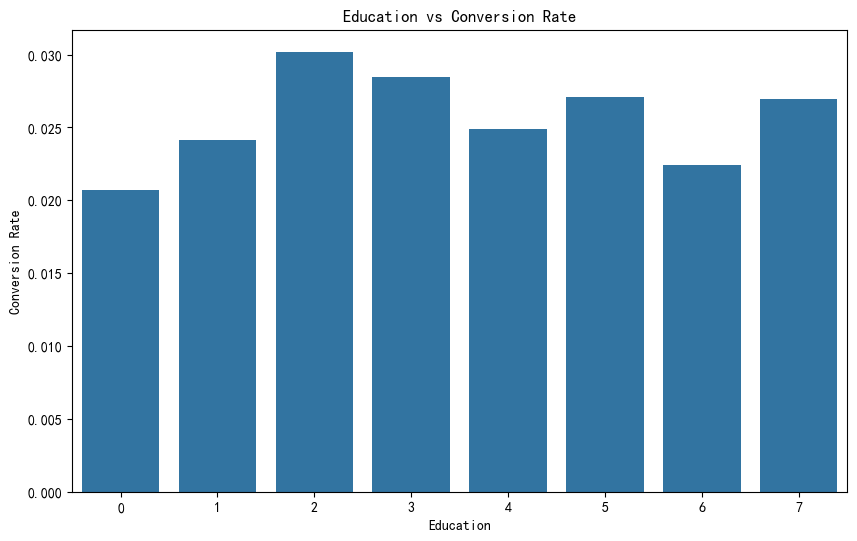

In [24]:
# 可视化学历转化率

# 统计
education_cvr_df = labeled_df.groupby('education').agg(
    cvr = ('label','mean')
).reset_index()

# 可视化
plt.figure(figsize=(10,6))
sns.barplot(x='education',y='cvr',data=education_cvr_df)
plt.title('Education vs Conversion Rate')
plt.xlabel('Education')
plt.ylabel('Conversion Rate')
plt.show()

##### app category 维度

In [25]:
# 合并app_cat表
if 'appCategory' not in labeled_df.columns:
    labeled_df = pd.merge(labeled_df,app_cat,on='appID',how='left')


In [26]:
labeled_df.columns

Index(['label', 'clickTime', 'creativeID', 'userID', 'positionID',
       'connectionType', 'telecomsOperator', 'adID', 'advertiserID', 'appID',
       'appPlatform', 'campaignID', 'age', 'gender', 'education',
       'marriageStatus', 'haveBaby', 'hometown', 'residence', 'appCategory'],
      dtype='object')

In [27]:
# 统计appCategory和appID的唯一值数
print(labeled_df['appID'].nunique())
print(labeled_df['appCategory'].nunique())


50
14


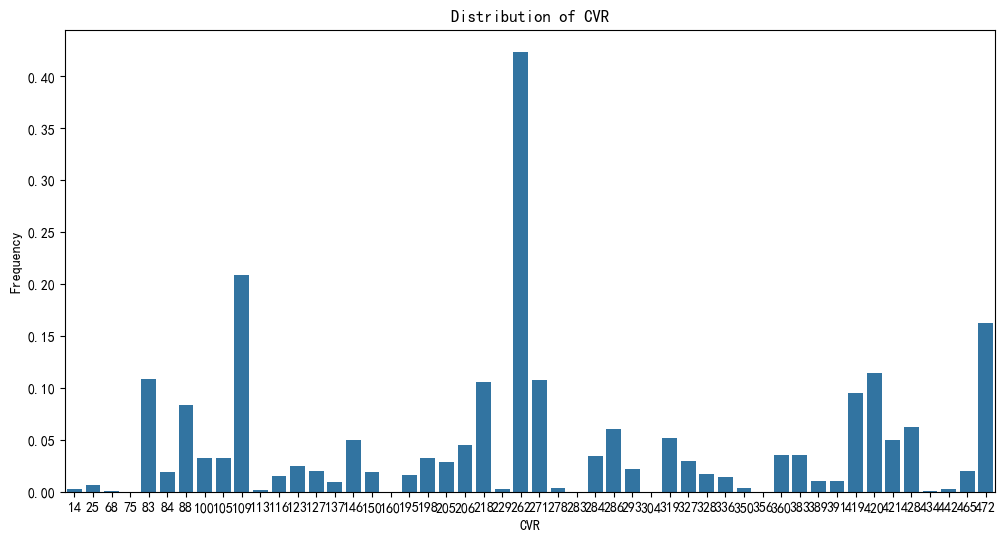

    appID  count       cvr
24    262    151  0.423841
9     109  32564  0.208727
49    472    129  0.162791
43    420  49645  0.114674
4      83  10113  0.108178
25    271   2344  0.107935
22    218   3712  0.105603
42    419     84  0.095238
6      88   4641  0.083172
45    428  25567  0.062072
            appID         count        cvr
count   50.000000  5.000000e+01  50.000000
mean   247.500000  7.384210e+04   0.044621
std    131.270285  2.736977e+05   0.070493
min     14.000000  6.200000e+01   0.000000
25%    124.000000  6.312500e+02   0.004451
50%    266.500000  6.250500e+03   0.021108
75%    354.500000  3.938550e+04   0.049801
max    472.000000  1.915847e+06   0.423841


In [28]:
#  app的转化率

app_cvr_df = labeled_df.groupby('appID').agg(
    count = ('label','count'),
    cvr = ('label','mean')
).reset_index().sort_values(by='cvr',ascending=False)


# 可视化
plt.figure(figsize=(12,6))
sns.barplot(x=app_cvr_df['appID'],y=app_cvr_df['cvr'])
plt.title('Distribution of CVR')
plt.xlabel('CVR')
plt.ylabel('Frequency')
plt.show()


# 打印一下前10个，看看count
print(app_cvr_df.head(10))
print(app_cvr_df.describe())


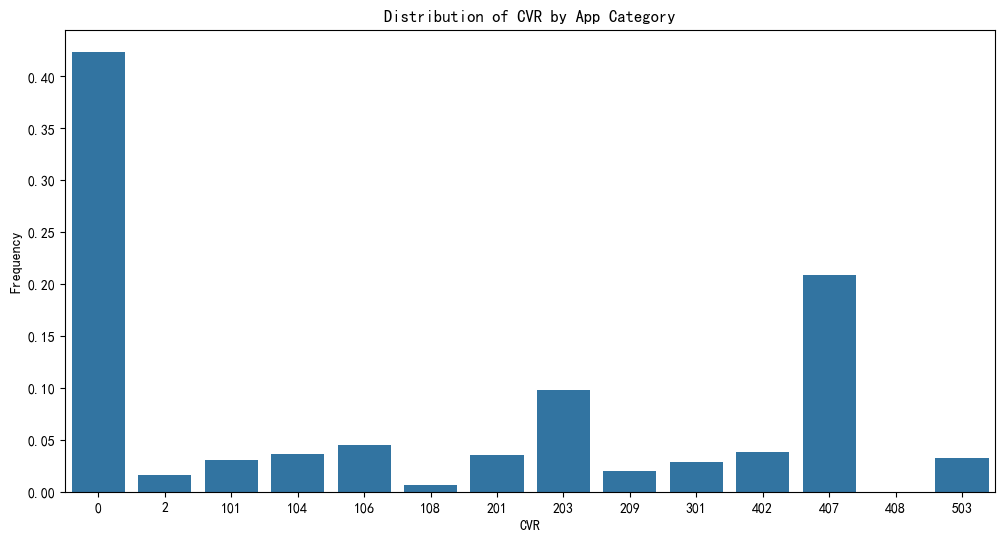

In [29]:
# 各分类的转化率

app_cat_cvr_df = labeled_df.groupby('appCategory').agg(
    count = ('label','count'),
    cvr = ('label','mean')
).reset_index()

# 可视化
plt.figure(figsize=(12,6))
sns.barplot(x=app_cat_cvr_df['appCategory'],y=app_cat_cvr_df['cvr'])
plt.title('Distribution of CVR by App Category')
plt.xlabel('CVR')
plt.ylabel('Frequency')
plt.show()


##### position 维度

In [30]:
position.columns

Index(['positionID', 'sitesetID', 'positionType'], dtype='object')

In [31]:
# 合并position表
if 'sitesetID' not in labeled_df.columns:
    labeled_df = pd.merge(labeled_df,position,on='positionID',how='left')

# positionID、sitesetID、positionType的唯一值数量
print(labeled_df['positionID'].nunique())
print(labeled_df['sitesetID'].nunique())
print(labeled_df['positionType'].nunique())

7219
3
6


In [32]:
# 各positionID的转化率

# 统计
positionID_cvr_df = labeled_df.groupby('positionID').agg(
    count = ('label','count'),
    cvr = ('label','mean')
).reset_index().sort_values(by='cvr',ascending = False)



# 筛选 计数>=50的positionID
positionID_cvr_filtered = positionID_cvr_df[positionID_cvr_df['count']>=50]
print(positionID_cvr_filtered.head(10))
print(positionID_cvr_filtered.describe())


      positionID  count       cvr
6467        6842   2073  0.322721
6621        7002     61  0.278689
6928        7332    183  0.240437
6414        6786     61  0.213115
2007        2091     71  0.211268
2599        2716     58  0.206897
2926        3059    169  0.195266
1259        1315     81  0.172840
3123        3269   1998  0.172673
801          847     58  0.155172
        positionID          count          cvr
count  1574.000000    1574.000000  1574.000000
mean   3741.148666    2318.601017     0.020899
std    2235.472146   13932.528998     0.028994
min       3.000000      50.000000     0.000000
25%    1817.000000     100.250000     0.000129
50%    3690.500000     251.000000     0.011645
75%    5637.750000     963.750000     0.028846
max    7643.000000  343192.000000     0.322721


1     986390
2      28771
0    2676944
Name: count, dtype: int64


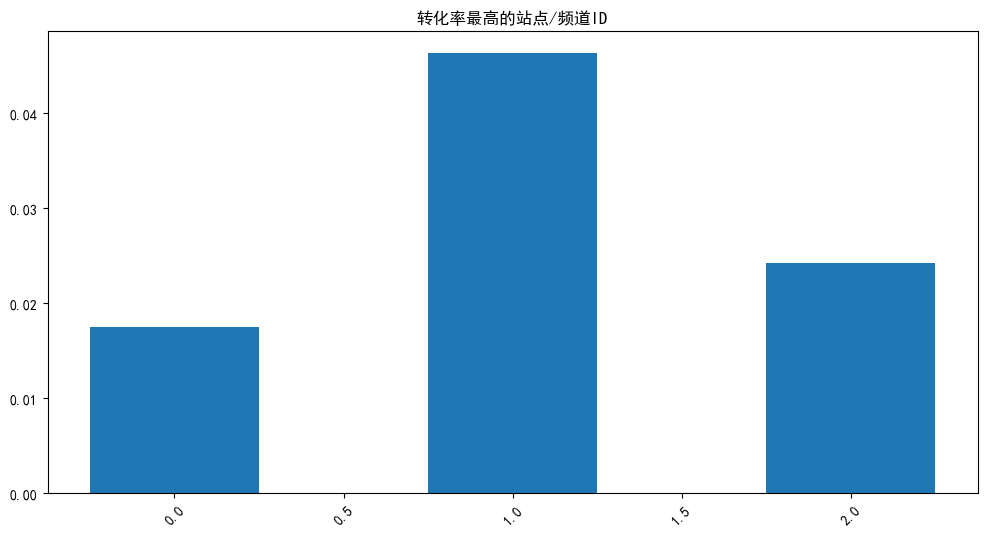

In [33]:
# 各sitesetID的转化率
sitesetID_cvr_df = labeled_df.groupby('sitesetID').agg(
    count = ('label','count'),
    cvr = ('label','mean')
).reset_index().sort_values(by='cvr',ascending = False)

# 组内计数
print(sitesetID_cvr_df['count'])

# cvr 可视化
plt.figure(figsize=(12,6))
plt.bar(sitesetID_cvr_df['sitesetID'],sitesetID_cvr_df['cvr'],width=0.5)
plt.title('转化率最高的站点/频道ID')
plt.xticks(rotation=45)
plt.show()



##### 时间维度 以clickTime为基础

In [34]:
labeled_df.columns

Index(['label', 'clickTime', 'creativeID', 'userID', 'positionID',
       'connectionType', 'telecomsOperator', 'adID', 'advertiserID', 'appID',
       'appPlatform', 'campaignID', 'age', 'gender', 'education',
       'marriageStatus', 'haveBaby', 'hometown', 'residence', 'appCategory',
       'sitesetID', 'positionType'],
      dtype='object')

In [35]:
# 新增一列index索引列
labeled_df['index'] = labeled_df.index

In [36]:
# 拆分hour和click_day(day特征后续不加入建模，只作时间维度分析使用)
labeled_df['click_hour'] = labeled_df['clickTime'].astype(str).str[2:4]
labeled_df['click_day'] = labeled_df['clickTime'].astype(str).str[0:2]


In [37]:
# 确认一下
labeled_df['click_hour'].nunique()

24

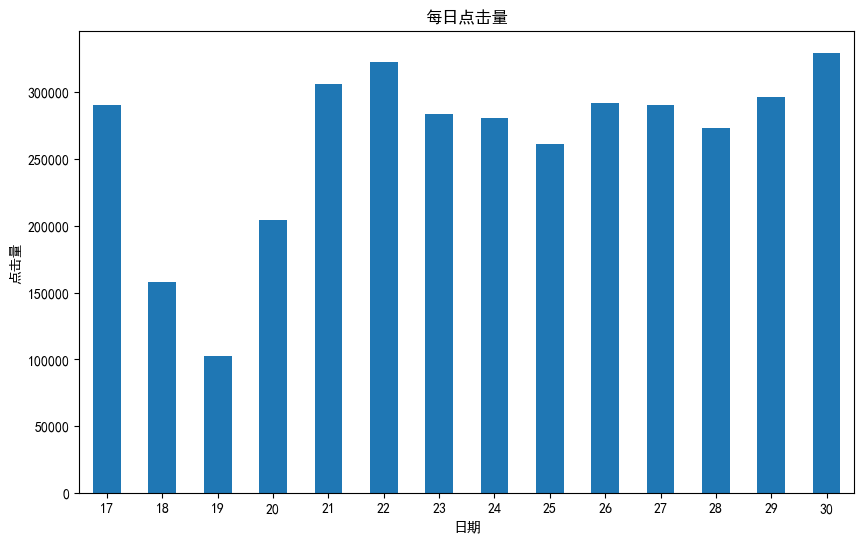

In [38]:
# 每日点击量
per_day_cl_quant_df = labeled_df.groupby('click_day')['index'].count()

# 可视化
plt.figure(figsize=(10, 6))
per_day_cl_quant_df.plot(kind='bar', title='每日点击量')
plt.xlabel('日期')
plt.ylabel('点击量')
plt.xticks(rotation=0)
plt.show()


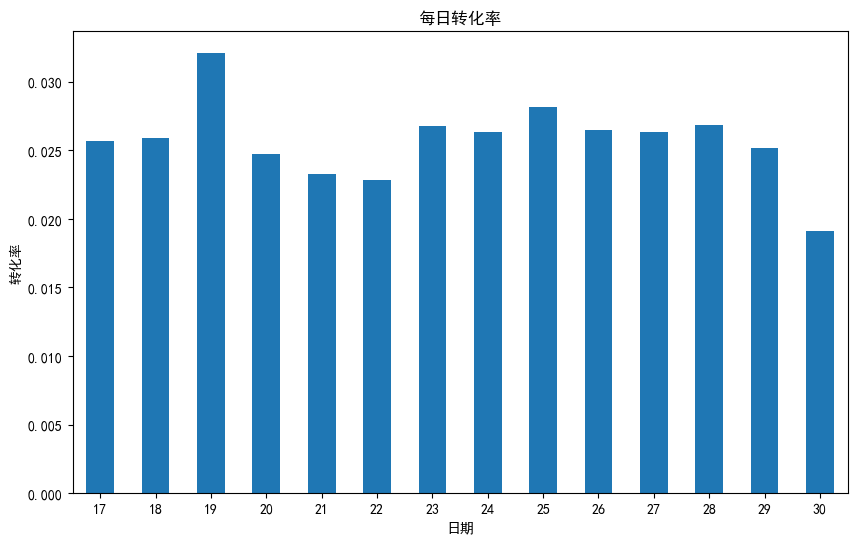

In [39]:
# 每日的转化率
per_day_cvr_df = labeled_df.groupby('click_day')['label'].mean().plot(kind='bar', figsize=(10, 6))

plt.ylabel('转化率')
plt.xlabel('日期')
plt.title('每日转化率')
plt.xticks(rotation=0)
plt.show()

<Axes: xlabel='click_day'>

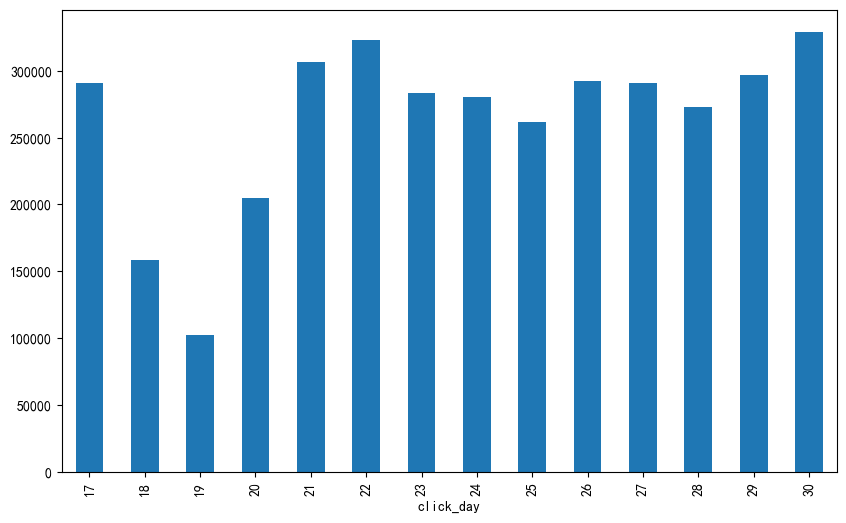

In [40]:
# 每日app点击量
labeled_df.groupby('click_day')['appID'].count().plot(kind='bar',figsize=(10,6)) 

<Axes: xlabel='click_hour'>

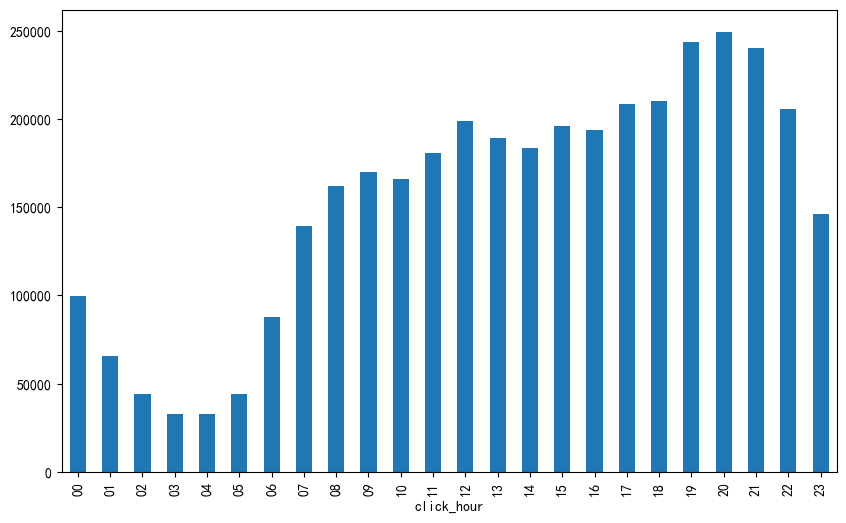

In [41]:
# 点击量小时分布
labeled_df['click_hour'].value_counts().sort_index().plot(kind='bar',figsize=(10,6))

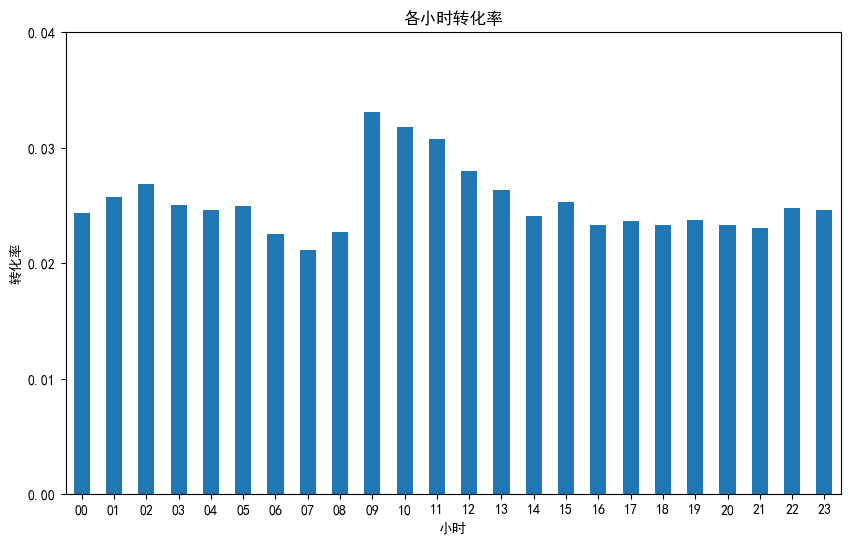

In [42]:
# 各小时的转化率
ax = labeled_df.groupby('click_hour')['label'].mean().plot(kind='bar', figsize=(10, 6))

# 设置y轴范围和刻度
ax.set_ylim(0, max(labeled_df.groupby('click_hour')['label'].mean()) * 1.1)
ax.set_yticks([i * 0.01 for i in range(0, int(max(labeled_df.groupby('click_hour')['label'].mean()) * 100) + 2)])

plt.ylabel('转化率')
plt.xlabel('小时')
plt.title('各小时转化率')
plt.xticks(rotation=0)
plt.show()

### Feature Engineering

In [43]:
# hometown拆分
def province_process(hometown):
    hometown = str(hometown)
    return int(hometown[:2])

def city_process(hometown):
    hometown=str(hometown)
    if len(hometown) >1:
        return int(hometown[2:])
    else:
        return 0
    

labeled_df['hometown_province'] = labeled_df['hometown'].apply(province_process)
labeled_df['hometown_city'] = labeled_df['hometown'].apply(city_process)

labeled_df.drop(columns = ['hometown'],inplace = True)

In [44]:
# category拆分
def cate_first_process(cate):
    # 获取 第一级 类目
    cate = str(cate)
    return int(cate[0])

def cate_second_process(cate):
    # 获取 第二级 类目
    cate = str(cate)
    if len(cate) < 3:
        return 0
    else:
        return int(cate[1:])

labeled_df['first_category'] = labeled_df['appCategory'].apply(cate_first_process)
labeled_df['second_category'] = labeled_df['appCategory'].apply(cate_second_process)


labeled_df.drop(columns = ['appCategory'],inplace = True)

In [45]:
labeled_df.shape

(3692105, 27)

In [46]:
labeled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3692105 entries, 0 to 3692104
Data columns (total 27 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   label              int64 
 1   clickTime          int64 
 2   creativeID         int64 
 3   userID             int64 
 4   positionID         int64 
 5   connectionType     int64 
 6   telecomsOperator   int64 
 7   adID               int64 
 8   advertiserID       int64 
 9   appID              int64 
 10  appPlatform        int64 
 11  campaignID         int64 
 12  age                int64 
 13  gender             int64 
 14  education          int64 
 15  marriageStatus     int64 
 16  haveBaby           int64 
 17  residence          int64 
 18  sitesetID          int64 
 19  positionType       int64 
 20  index              int64 
 21  click_hour         object
 22  click_day          object
 23  hometown_province  int64 
 24  hometown_city      int64 
 25  first_category     int64 
 26  second_categor

In [47]:
# 删无用列
labeled_df = labeled_df.drop(columns=['click_day','index'])


In [48]:
# 统计各列唯一值
labeled_df.nunique()

label                      2
clickTime              20160
creativeID              6315
userID               2595627
positionID              7219
connectionType             5
telecomsOperator           4
adID                    3447
advertiserID              89
appID                     50
appPlatform                2
campaignID               677
age                       81
gender                     3
education                  8
marriageStatus             4
haveBaby                   7
residence                399
sitesetID                  3
positionType               6
click_hour                24
hometown_province         39
hometown_city             17
first_category             6
second_category            9
dtype: int64

In [49]:
# 转换clickTime为时间戳hour_since_start
labeled_df['day'] = labeled_df['clickTime'].astype(str).str[0:2].astype(int)
labeled_df['hour'] = labeled_df['clickTime'].astype(str).str[2:4].astype(int)
labeled_df['minute'] = labeled_df['clickTime'].astype(str).str[4:6].astype(int) 

# 计算从第0天0时开始的小时数（包含分钟为小数）
labeled_df['hours_since_start'] = labeled_df['day'] * 24 + labeled_df['hour'] + labeled_df['minute'] / 60.0

labeled_df.drop(columns=['day', 'hour', 'minute','clickTime'], inplace=True)


In [50]:
#  定义特征和标签
target = 'label'
feature_cols = [col for col in labeled_df.columns if col != target]

X = labeled_df[feature_cols]
y = labeled_df[target]

In [51]:
from sklearn.model_selection import train_test_split

#  划分训练集和验证集（分层采样保证正负比例，或者按时间顺序）
# 按 hours_since_start 排序，确保时间顺序
df_temp = pd.concat([X, y], axis=1)
df_temp = df_temp.sort_values('hours_since_start')  # 按时间升序

# 划分比例
split_ratio = 0.7
split_idx = int(len(df_temp) * split_ratio)

train_data = df_temp.iloc[:split_idx]
valid_data = df_temp.iloc[split_idx:]

X_train = train_data.drop(columns=['label'])
y_train = train_data['label']
X_valid = valid_data.drop(columns=['label'])
y_valid = valid_data['label']

# 可选：重置索引
X_train = X_train.reset_index(drop=True)
X_valid = X_valid.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)

In [52]:
# 高基数交叉如userID_adID等 阈值120条下折叠为other，内存跑不了 
# 只加几个低基数交叉  也跑不了

In [53]:
# 指定类别特征列名
#    根据唯一值数量和业务含义，将以下特征设为类别特征
cat_features = [
    'creativeID', 'userID', 'positionID', 'connectionType', 'telecomsOperator',
    'adID', 'advertiserID', 'appID', 'appPlatform', 'campaignID', 'gender',
    'education', 'marriageStatus', 'haveBaby', 'residence', 'sitesetID',
    'positionType', 'click_hour', 'hometown_province', 'hometown_city',
    'first_category', 'second_category' 
    # 'positionID_sitesetID','appID_positionType','appID_adID','appID_campaignID','appID_advertiserID'
]

# 注意：age 虽然是整数但通常作为数值特征；click_hour,hours_since_start 若希望作为周期特征可保留数值或放入类别
#     这里保留 click_hour,hours_since_start   为数值，若希望类别可将其移入 cat_features

# 可选：确保类别特征在 pandas 中是 object 或 category 类型（CatBoost 也接受 int，但指定 cat_features 即可）
for col in cat_features:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype('category')
        X_valid[col] = X_valid[col].astype('category')

### model training

In [ ]:
# 训练catboost模型
from catboost import CatBoostClassifier,Pool

# 创建 CatBoost 分类器（自动处理类别特征，无需手动目标编码）

train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool = Pool(X_valid, y_valid, cat_features=cat_features)


model = CatBoostClassifier(
    iterations=500,               # 树的数量，可根据验证集早停调整
    learning_rate=0.03,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    cat_features=cat_features,    # 指定类别特征索引或列名

    random_seed=42,
    verbose=100,                  # 每100轮输出一次日志
    early_stopping_rounds=50      # 验证集AUC不提升50轮则早停
)

# 训练模型（使用验证集）
# 3. 训练并早停
model.fit(
    train_pool,
    eval_set=test_pool,
    early_stopping_rounds=50,
    verbose=100
)

In [ ]:

from sklearn.metrics import roc_auc_score


# 预测验证集并评估
y_pred_proba = model.predict_proba(X_valid)[:, 1]
auc = roc_auc_score(y_valid, y_pred_proba)
print(f"验证集 AUC: {auc:.4f}")

# 特征重要性
feature_importance = model.get_feature_importance()
feat_imp_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)
print("\nTop 10 重要特征:")
print(feat_imp_df)


验证集 AUC: 0.7720

Top 10 重要特征:
              feature  importance
3      connectionType   17.085228
1              userID   12.156173
2          positionID   10.178746
16          sitesetID   10.132110
8         appPlatform    9.227803
9          campaignID    4.793991
7               appID    4.679325
21     first_category    4.225552
15          residence    4.161254
5                adID    3.796790
0          creativeID    3.482736
22    second_category    2.833878
11             gender    2.709140
17       positionType    2.619352
6        advertiserID    2.366722
10                age    1.814780
18         click_hour    1.152868
13     marriageStatus    0.917867
19  hometown_province    0.535735
12          education    0.481301
23  hours_since_start    0.299866
4    telecomsOperator    0.132565
20      hometown_city    0.123706
14           haveBaby    0.092512


In [ ]:
"""

# 创建 CatBoost 分类器（自动处理类别特征，无需手动目标编码）

model = CatBoostClassifier(
    iterations=500,               # 树的数量，可根据验证集早停调整
    learning_rate=0.03,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    cat_features=cat_features,    # 指定类别特征索引或列名

    random_seed=42,
    verbose=100,                  # 每100轮输出一次日志
    early_stopping_rounds=50      # 验证集AUC不提升50轮则早停
)
# 训练模型（使用验证集）
model.fit(
    X_train, y_train,
    eval_set=(X_valid, y_valid),
    verbose=100,# 每100轮输出一次日志
    plot=False                   # 若在Jupyter中可设为True显示实时图表
)
0:	test: 0.5000000	best: 0.5000000 (0)	total: 823ms	remaining: 6m 50s
100:	test: 0.7591041	best: 0.7591041 (100)	total: 4m 23s	remaining: 17m 22s
200:	test: 0.7666051	best: 0.7666051 (200)	total: 14m	remaining: 20m 49s
300:	test: 0.7690723	best: 0.7691742 (297)	total: 22m 39s	remaining: 14m 58s
400:	test: 0.7713061	best: 0.7713061 (400)	total: 29m 5s	remaining: 7m 10s
499:	test: 0.7719656	best: 0.7719935 (493)	total: 34m 35s	remaining: 0us

bestTest = 0.7719935091
bestIteration = 493

Shrink model to first 494 iterations.


验证集 AUC: 0.7720

Top 10 重要特征:
              feature  importance
3      connectionType   17.085228
1              userID   12.156173
2          positionID   10.178746
16          sitesetID   10.132110
8         appPlatform    9.227803
9          campaignID    4.793991
7               appID    4.679325
21     first_category    4.225552
15          residence    4.161254
5                adID    3.796790
0          creativeID    3.482736
22    second_category    2.833878
11             gender    2.709140
17       positionType    2.619352
6        advertiserID    2.366722
10                age    1.814780
18         click_hour    1.152868
13     marriageStatus    0.917867
19  hometown_province    0.535735
12          education    0.481301
23  hours_since_start    0.299866
4    telecomsOperator    0.132565
20      hometown_city    0.123706
14           haveBaby    0.092512
"""

"\n\n# 创建 CatBoost 分类器（自动处理类别特征，无需手动目标编码）\n\nmodel = CatBoostClassifier(\n    iterations=500,               # 树的数量，可根据验证集早停调整\n    learning_rate=0.03,\n    depth=6,\n    loss_function='Logloss',\n    eval_metric='AUC',\n    cat_features=cat_features,    # 指定类别特征索引或列名\n\n    random_seed=42,\n    verbose=100,                  # 每100轮输出一次日志\n    early_stopping_rounds=50      # 验证集AUC不提升50轮则早停\n)\n# 训练模型（使用验证集）\nmodel.fit(\n    X_train, y_train,\n    eval_set=(X_valid, y_valid),\n    verbose=100,# 每100轮输出一次日志\n    plot=False                   # 若在Jupyter中可设为True显示实时图表\n)\n0:\ttest: 0.5000000\tbest: 0.5000000 (0)\ttotal: 823ms\tremaining: 6m 50s\n100:\ttest: 0.7591041\tbest: 0.7591041 (100)\ttotal: 4m 23s\tremaining: 17m 22s\n200:\ttest: 0.7666051\tbest: 0.7666051 (200)\ttotal: 14m\tremaining: 20m 49s\n300:\ttest: 0.7690723\tbest: 0.7691742 (297)\ttotal: 22m 39s\tremaining: 14m 58s\n400:\ttest: 0.7713061\tbest: 0.7713061 (400)\ttotal: 29m 5s\tremaining: 7m 10s\n499:\ttest: 0.7719656\tbest: 